In [38]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/220125_AI_ML/Task_2/Titanic-Dataset.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nBasic Statistics:")
df.describe()

Shape: (891, 12)

Column Names:
 ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Basic Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


/tmp/ipykernel_4063/653020095.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.index, y=missing.values, palette='flare')


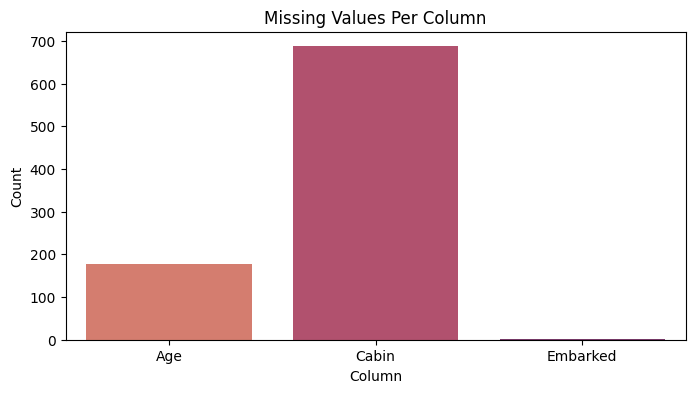

Age         177
Cabin       687
Embarked      2
dtype: int64


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(8, 4))
sns.barplot(x=missing.index, y=missing.values, palette='flare')
plt.title('Missing Values Per Column')
plt.ylabel('Count')
plt.xlabel('Column')
plt.show()

print(missing)

/tmp/ipykernel_4063/3637412435.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


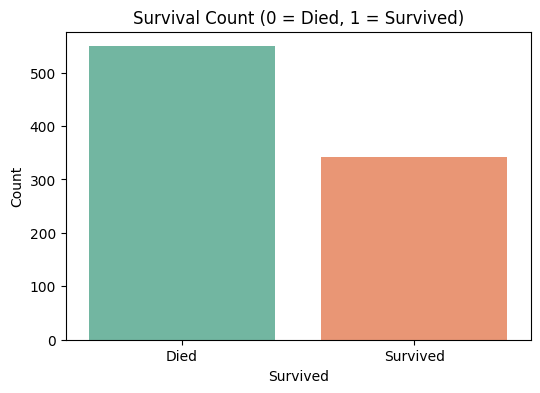

In [41]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.ylabel('Count')
plt.show()

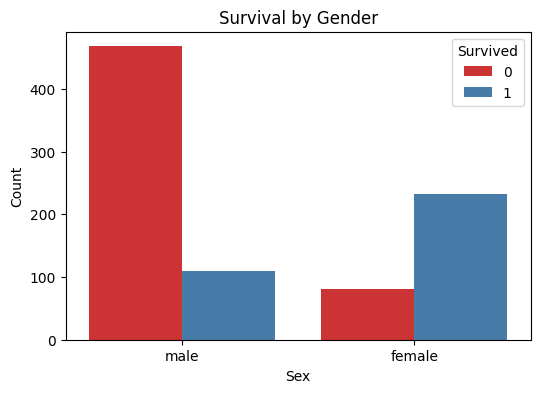

In [42]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set1')
plt.title('Survival by Gender')
plt.ylabel('Count')
plt.show()

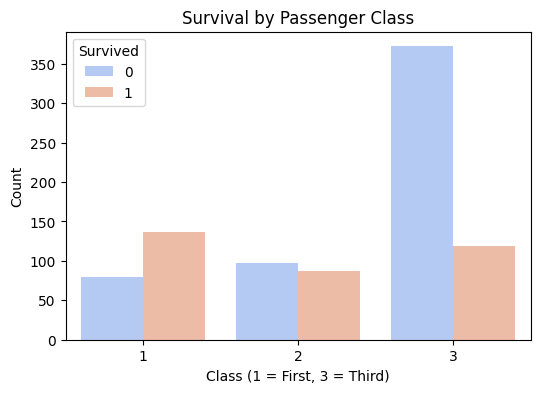

In [43]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='coolwarm')
plt.title('Survival by Passenger Class')
plt.xlabel('Class (1 = First, 3 = Third)')
plt.ylabel('Count')
plt.show()

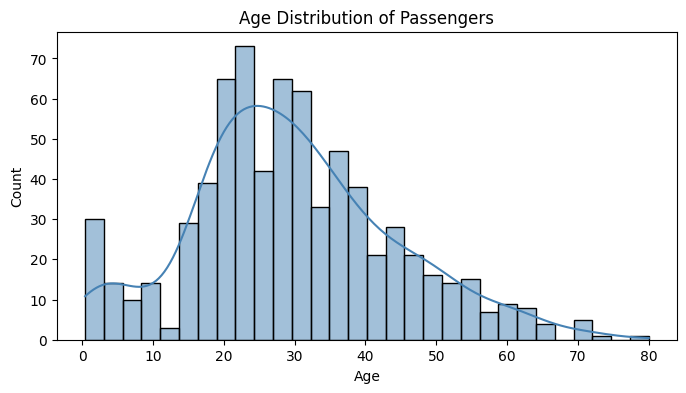

In [44]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_4063/2663673237.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=df, palette='pastel')


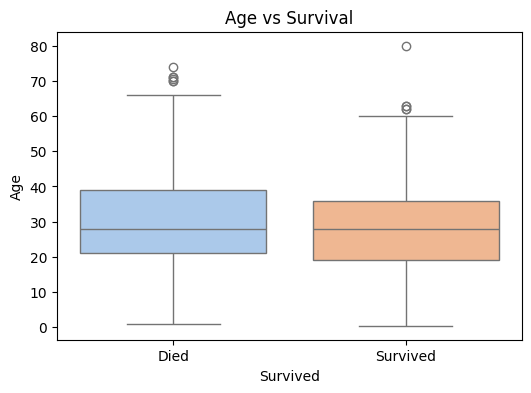

In [45]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Survived', y='Age', data=df, palette='pastel')
plt.title('Age vs Survival')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()

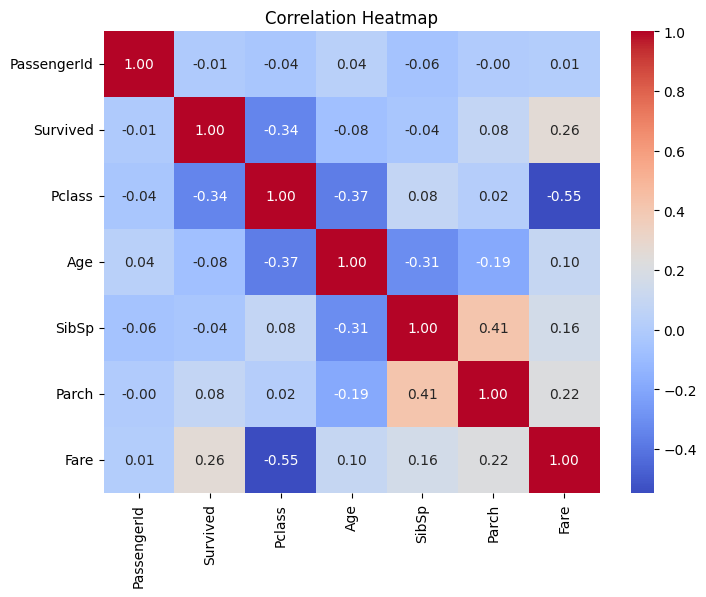

In [46]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [47]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


Fill missing Age with median
Fill missing Embarked with mode
Confirm no missing values remain

In [48]:

df['Age'].fillna(df['Age'].median(), inplace=True)

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print("Missing values after fix:\n", df.isnull().sum())

Missing values after fix:
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


/tmp/ipykernel_4063/943980382.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_4063/943980382.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [49]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()


df['Sex'] = le.fit_transform(df['Sex'])


df['Embarked'] = le.fit_transform(df['Embarked'])

print(df[['Sex', 'Embarked']].head())

   Sex  Embarked
0    1         2
1    0         0
2    0         2
3    0         2
4    1         2


In [50]:
X = df.drop(columns=['Survived'])
y = df['Survived']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nSample features:\n", X.head())

Features shape: (891, 7)
Target shape: (891,)

Sample features:
    Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    1  22.0      1      0   7.2500         2
1       1    0  38.0      1      0  71.2833         0
2       3    0  26.0      0      0   7.9250         2
3       1    0  35.0      1      0  53.1000         2
4       3    1  35.0      0      0   8.0500         2


Spliting-(80,20)

In [51]:
from sklearn.model_selection import train_test_split


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train size:      {X_train.shape[0]} rows")
print(f"Validation size: {X_val.shape[0]} rows")
print(f"Test size:       {X_test.shape[0]} rows")

Train size:      534 rows
Validation size: 178 rows
Test size:       179 rows


In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("Scaling complete. Sample of scaled training data:")
print(X_train[:3])

Scaling complete. Sample of scaled training data:
[[-1.57108416 -1.35107247  0.70563345  0.46845276 -0.47172818  0.53493678
   0.59791648]
 [ 0.83280965  0.74015275 -1.96006216  2.32833213  1.86070559 -0.07261663
   0.59791648]
 [ 0.83280965  0.74015275 -0.89378392  0.46845276  0.6944887  -0.23942258
   0.59791648]]


In [53]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model training complete!")
print("Number of iterations run:", model.n_iter_)

Model training complete!
Number of iterations run: [9]


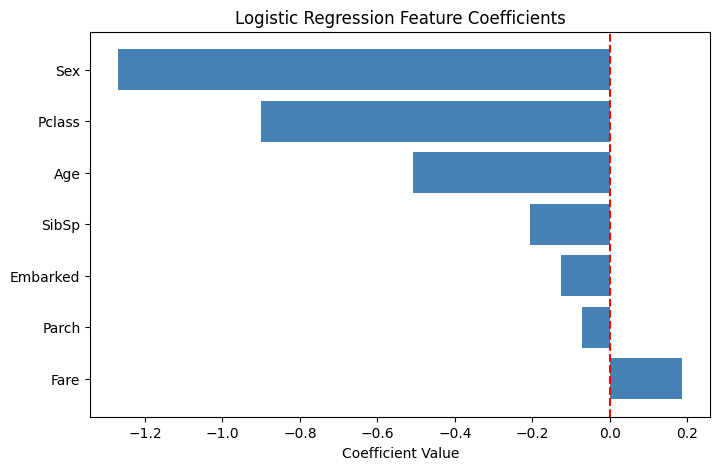

    Feature  Coefficient
5      Fare     0.185958
4     Parch    -0.072957
6  Embarked    -0.125644
3     SibSp    -0.205199
2       Age    -0.508542
0    Pclass    -0.899561
1       Sex    -1.268587


In [54]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

coeff_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Logistic Regression Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.show()

print(coeff_df)

In [55]:
from sklearn.metrics import accuracy_score

# Predict on validation set
y_val_pred = model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

Validation Accuracy: 0.7865 (78.65%)


In [56]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score,
                              classification_report)

y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)[:, 1]


print("           MODEL EVALUATION METRICS")

print(f"Accuracy  : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_test_pred):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_test_prob):.4f}")
print("=" * 40)
print("\nFull Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Died', 'Survived']))

           MODEL EVALUATION METRICS
Accuracy  : 0.7877
Precision : 0.7541
Recall    : 0.6667
F1-Score  : 0.7077
AUC-ROC   : 0.8474

Full Classification Report:
              precision    recall  f1-score   support

        Died       0.81      0.86      0.83       110
    Survived       0.75      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179



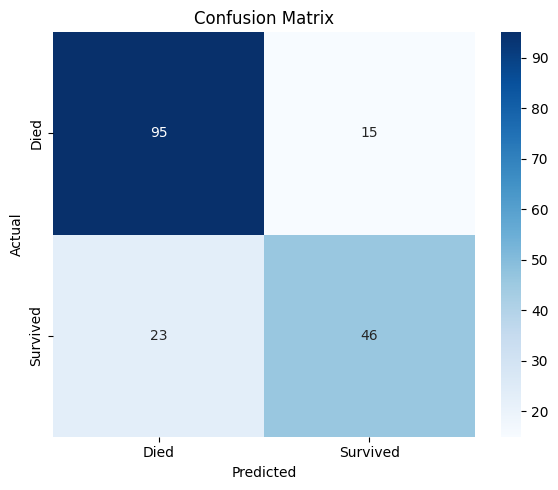

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

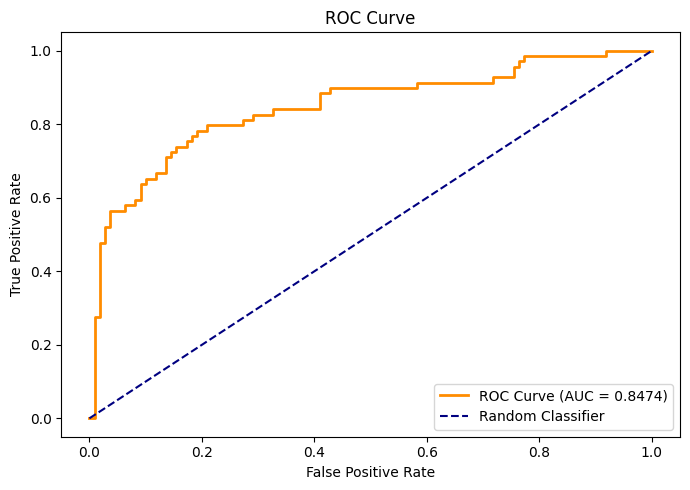

In [58]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
auc_score = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
         label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [59]:
import numpy as np

results_df = pd.DataFrame({
    'Actual':      y_test.values,
    'Predicted':   y_test_pred,
    'Probability': np.round(y_test_prob, 4)
})

results_df['Result'] = results_df.apply(
    lambda row: ' Correct' if row['Actual'] == row['Predicted'] else ' Wrong', axis=1)

print("Sample Predictions (first 15):")
print(results_df.head(15).to_string(index=False))

Sample Predictions (first 15):
 Actual  Predicted  Probability   Result
      0          0       0.0779  Correct
      0          0       0.0482  Correct
      1          0       0.1454    Wrong
      0          0       0.0403  Correct
      1          1       0.5835  Correct
      1          0       0.4701    Wrong
      1          1       0.7567  Correct
      0          0       0.3249  Correct
      0          0       0.3747  Correct
      0          0       0.1709  Correct
      0          0       0.1038  Correct
      0          0       0.1010  Correct
      1          1       0.5942  Correct
      0          0       0.2325  Correct
      0          1       0.6195    Wrong


In [60]:

print("        FINAL MODEL SUMMARY")

print(f"  Dataset       : Titanic (Kaggle)")
print(f"  Model         : Logistic Regression")
print(f"  Train size    : {X_train.shape[0]} samples")
print(f"  Val size      : {X_val.shape[0]} samples")
print(f"  Test size     : {X_test.shape[0]} samples")
print("-" * 45)
print(f"  Accuracy      : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  Precision     : {precision_score(y_test, y_test_pred):.4f}")
print(f"  Recall        : {recall_score(y_test, y_test_pred):.4f}")
print(f"  F1-Score      : {f1_score(y_test, y_test_pred):.4f}")
print(f"  AUC-ROC       : {roc_auc_score(y_test, y_test_prob):.4f}")




        FINAL MODEL SUMMARY
  Dataset       : Titanic (Kaggle)
  Model         : Logistic Regression
  Train size    : 534 samples
  Val size      : 178 samples
  Test size     : 179 samples
---------------------------------------------
  Accuracy      : 0.7877
  Precision     : 0.7541
  Recall        : 0.6667
  F1-Score      : 0.7077
  AUC-ROC       : 0.8474
